# Zero-shot Quickstart (Single Sample)

This quickstart embeds a **single** spatial transcriptomics sample with a pretrained TERRA model — no training required — and uses the embeddings to identify cell types and spatial niches.

**You will:**
1. Download a public single-cell-resolution spatial dataset (10x Xenium).
2. Download a pretrained TERRA model from the Hugging Face Hub.
3. Run the harmonize → tokenize → embed pipeline to obtain **cell** and **neighborhood** embeddings.
4. Visualize and cluster the embeddings.

:::{note}
**TERRA requires an NVIDIA GPU** for the embedding step.
:::

Working with several sections or donors? See {doc}`zero_shot_quickstart_multisample`. For gene-level analyses, see {doc}`downstream_analysis`. Setup details are in the {doc}`../installation` guide and concepts in the {doc}`../user_guide`.

## 1. Setup

In [1]:
import logging

import numpy as np
import scanpy as sc
import squidpy as sq

from terra import download_pretrained, harmonize_tokenize_embed_pipeline
from terra.datasets import read_xenium_10x

logging.basicConfig(level="INFO")  # see TERRA progress
sc.settings.set_figure_params(dpi=80, frameon=False)

/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


## 2. Download the demo dataset

We use the 10x Genomics **Xenium Prime FFPE Human Skin** sample — human, single-cell resolution, raw counts, and the 5,000-gene Xenium Prime panel (an established standard; TERRA also works with smaller panels). `read_xenium_10x` downloads and assembles it for you.

In [2]:
# Xenium Prime FFPE Human Skin (5,000-gene panel). The reader downloads the
# two small standalone files (~44 MB) on first run and caches them.
adata = read_xenium_10x(
    "https://cf.10xgenomics.com/samples/xenium/3.0.0/Xenium_Prime_Human_Skin_FFPE/Xenium_Prime_Human_Skin_FFPE",
    "data/xenium_skin",
)
adata.obs["cell_id"] = adata.obs_names.astype(str)
adata.obs["sample"] = "skin"

# Crop a contiguous tissue window (so spatial neighborhoods stay intact) to keep
# the tutorial fast. Centre it on the median cell position -- the bounding-box
# corner is often empty space. Widen `half_window` (microns) for more cells.
xy = adata.obsm["spatial"]
center = np.median(xy, axis=0)
half_window = 500
keep = (np.abs(xy - center) <= half_window).all(axis=1)
adata = adata[keep].copy()
print(adata)

AnnData object with n_obs × n_vars = 8180 × 5006
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'cell_id', 'sample'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial'


... storing 'segmentation_method' as categorical
... storing 'sample' as categorical
... storing 'feature_types' as categorical
... storing 'genome' as categorical


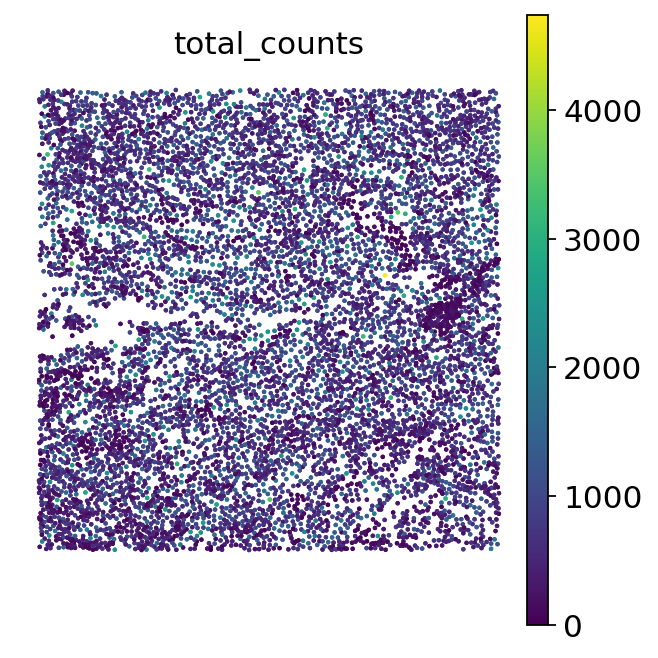

In [3]:
# Quick look: total counts per cell, in space.
adata.obs["total_counts"] = np.asarray(adata.X.sum(axis=1)).ravel()
sq.pl.spatial_scatter(adata, color="total_counts", shape=None, size=4)

## 3. Download a pretrained TERRA model

`download_pretrained` fetches a self-contained model bundle (checkpoint, tokenizer, and the gene-reference files used for harmonization) and returns the local folder path.

In [4]:
# By default the model is cached in the Hugging Face cache; pass
# local_dir="terra_model" to download it into a folder of your choice.
model_dir = download_pretrained("Lotfollahi-lab/TERRA-112M")

INFO:httpx:HTTP Request: GET https://huggingface.co/api/agent-harnesses "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/Lotfollahi-lab/TERRA-112M/revision/main "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/lotfollahi-lab/TERRA-112M/revision/main "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/Lotfollahi-lab/TERRA-112M/tree/00d1c977e49364ba10c28692abcbd102e115bf91?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/lotfollahi-lab/TERRA-112M/tree/00d1c977e49364ba10c28692abcbd102e115bf91?recursive=true&expand=false "HTTP/1.1 200 OK"


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

## 4. Embed the data (zero-shot)

`harmonize_tokenize_embed_pipeline` runs the full workflow: it maps genes to the model's vocabulary, builds the per-cell neighborhood token sequences, and runs the model. The embeddings land in `adata.obsm`.

In [5]:
adata = harmonize_tokenize_embed_pipeline(
    adata=adata,
    sample_key=None,          # a single sample
    batch_key="sample",
    model_folder_path=model_dir,
    cache_directory_path="./terra_cache",
    batch_size=128,           # lower this if you run out of GPU memory
)
# Zero-shot embeddings now live in adata.obsm:
#   "cell_emb"         -> each cell's own expression
#   "neighborhood_emb" -> the cell together with its spatial neighborhood
print(list(adata.obsm))

INFO:terra.inference.embed:Harmonizing AnnData...
INFO:terra.inference.harmonize:STEP 1: DATA VALIDATION...
INFO:terra.inference.harmonize:Checking that adata.X contains raw counts...
INFO:terra.inference.harmonize:✓ adata.X contains raw counts (integer values).
INFO:terra.inference.harmonize:STEP 2: ADDING ENSEMBL IDS...
INFO:terra.inference.harmonize:Adding ensembl IDs from gene_mapping_dict with file path `/nfs/users/nfs_s/sb75/.cache/huggingface/hub/models--Lotfollahi-lab--TERRA-112M/snapshots/00d1c977e49364ba10c28692abcbd102e115bf91/ensembl_dictionary.pkl`...
INFO:terra.inference.harmonize:Number of genes with matching ensembl IDs: 4957.
INFO:terra.inference.harmonize:Filtering genes that have not occurred enough during pretraining...
INFO:terra.inference.harmonize:STEP 3: BASIC QUALITY CONTROL...
INFO:terra.inference.harmonize:Filtering cells with less than 0 genes.
INFO:terra.inference.harmonize:Before cell filtering: 8180 cells.
INFO:terra.inference.harmonize:After cell filteri

Setting num_proc from 4 back to 1 for the train split to disable multiprocessing as it only contains one shard.


Generating train split: 0 examples [00:00, ? examples/s]

INFO:terra.tokenizers.cell_tokenizers:Formatting gene tokens...


Map (num_proc=4):   0%|          | 0/8180 [00:00<?, ? examples/s]

INFO:terra.inference.embed:Embedding tokenized data...
INFO:terra.inference.embed:STEP 1: LOADING CONFIG...
INFO:terra.inference.embed:STEP 2: GENERATING EMBEDDINGS...
INFO:terra.utils.helper:Protein-init: DISABLED -- using the default learnable nn.Embedding for gene tokens.
INFO:terra.utils.helper:EncoderMultiMaskWrapper(
  (backbone): GeneTransformerCombinedEncoder(
    (token_embed): Embedding(23407, 384, padding_idx=0)
    (seg_embed): Embedding(13, 384, padding_idx=0)
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=384, out_features=1152, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=384, out_features=384, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (mlp): MLP(
          (fc1): Linear

/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 6, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


INFO:terra.utils.helper:Loaded pretrained target encoder from epoch 1 with msg: <All keys matched successfully>.
INFO:terra.utils.helper:Finished loading checkpoint with read path: /nfs/users/nfs_s/sb75/.cache/huggingface/hub/models--Lotfollahi-lab--TERRA-112M/snapshots/00d1c977e49364ba10c28692abcbd102e115bf91/model_checkpoint.pt.


0it [00:00, ?it/s]/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/terra/inference/embed.py:265: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(
64it [02:08,  2.00s/it]

INFO:terra.inference.embed:Embedded tokenized data.
['spatial', 'cell_emb', 'neighborhood_emb', 'spatial_cell_emb']


### Sanity check: are the embeddings informative?

A very high average cosine similarity (≈1) means the embeddings have collapsed and carry little signal.

In [6]:
for emb_key in ["cell_emb", "neighborhood_emb"]:
    X = adata.obsm[emb_key]
    X = X / np.linalg.norm(X, axis=1, keepdims=True)
    n = X.shape[0]
    S = X.sum(axis=0)
    avg_cos = (S @ S - n) / (n * (n - 1))
    print(f"{emb_key}: average cosine similarity = {avg_cos:.3f}")

cell_emb: average cosine similarity = nan
neighborhood_emb: average cosine similarity = 0.880


/tmp/ipykernel_1903304/400976480.py:3: RuntimeWarning: invalid value encountered in divide
  X = X / np.linalg.norm(X, axis=1, keepdims=True)


## 5. Visualize the embeddings

Compute a UMAP for each embedding space.

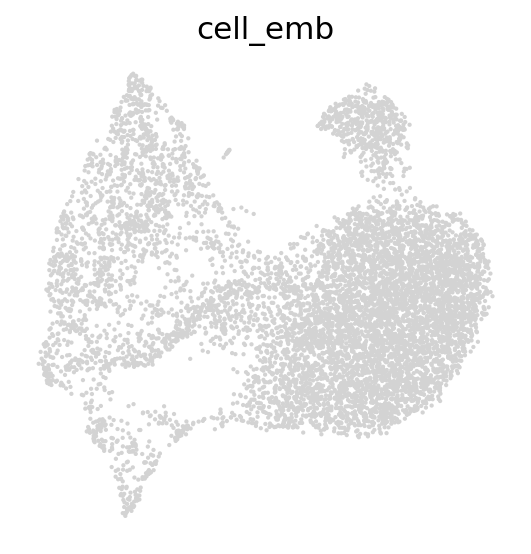

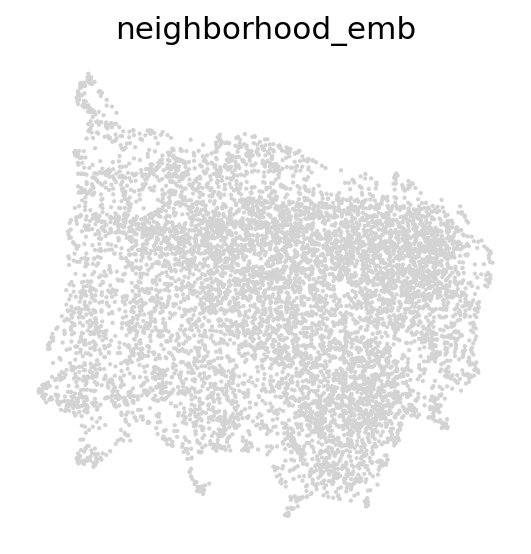

In [7]:
for emb_key in ["cell_emb", "neighborhood_emb"]:
    sc.pp.neighbors(adata, use_rep=emb_key, key_added=emb_key)
    sc.tl.umap(adata, neighbors_key=emb_key)
    sc.pl.umap(adata, neighbors_key=emb_key, title=emb_key)

## 6. Niche & cell-type identification

Cluster the **neighborhood** embedding to find spatial **niches**, and the **cell** embedding to find **cell types**.

In [8]:
sc.tl.leiden(adata, neighbors_key="neighborhood_emb", key_added="niche",
             resolution=0.6, flavor="igraph", n_iterations=2, directed=False)
sc.tl.leiden(adata, neighbors_key="cell_emb", key_added="cell_type",
             resolution=0.6, flavor="igraph", n_iterations=2, directed=False)

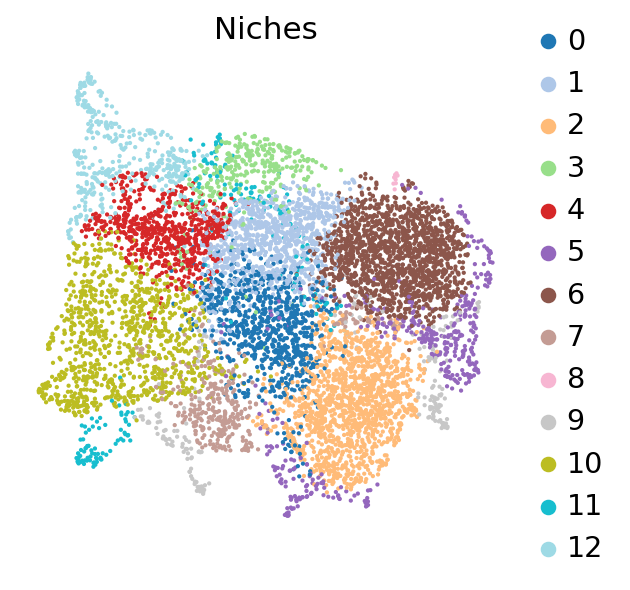

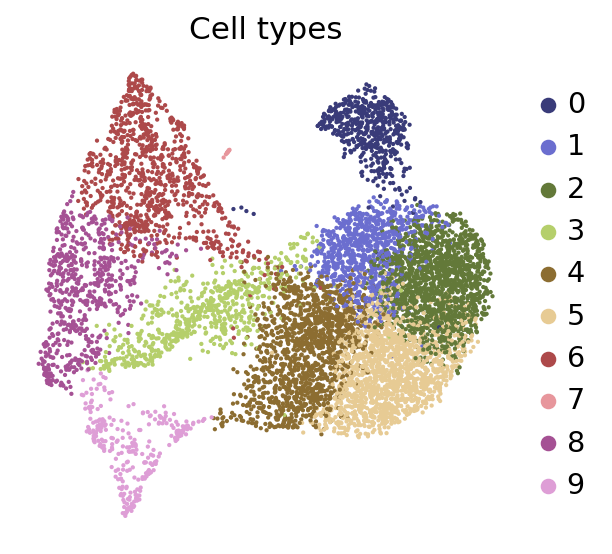

In [9]:
sc.tl.umap(adata, neighbors_key="neighborhood_emb")
sc.pl.umap(adata, neighbors_key="neighborhood_emb", color="niche",
           palette="tab20", title="Niches")

sc.tl.umap(adata, neighbors_key="cell_emb")
sc.pl.umap(adata, neighbors_key="cell_emb", color="cell_type",
           palette="tab20b", title="Cell types")

/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


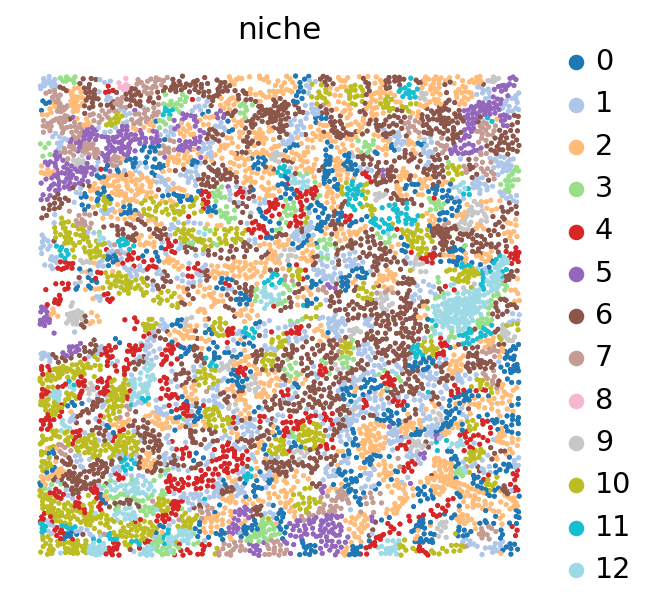

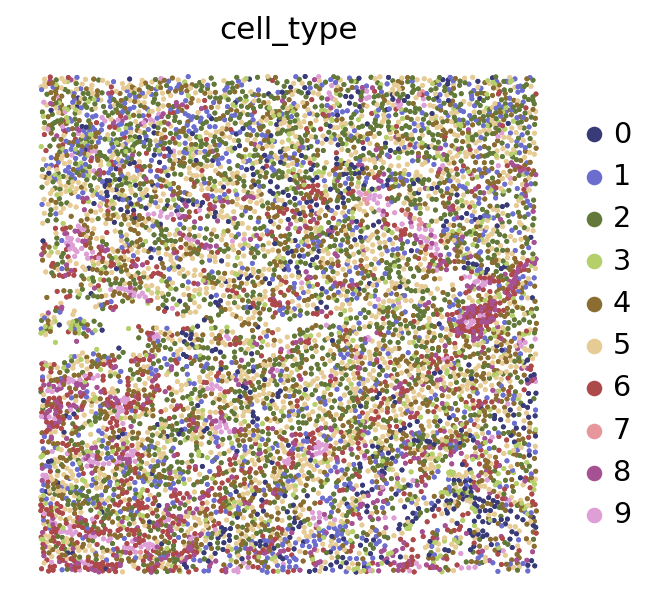

In [10]:
# Niches and cell types in space, with distinct colour palettes.
sq.pl.spatial_scatter(adata, color="niche", shape=None, size=6, palette="tab20")
sq.pl.spatial_scatter(adata, color="cell_type", shape=None, size=6, palette="tab20b")

## Next steps

- {doc}`zero_shot_quickstart_multisample` — the same workflow across multiple sections/donors with batch integration.
- {doc}`downstream_analysis` — gene-level embeddings, spatial gene-pair scores, EMD spatial structure, and in-silico perturbation.
- {doc}`supervised_finetuning` and {doc}`xenium_finetuning` — adapt the pretrained model to your own data.

**Questions or issues?** Please report them on the [TERRA GitHub repository](https://github.com/Lotfollahi-lab/terra/issues).